# 03 Imbalance Experiment

Purpose: Simulate retrieval-time class imbalance and evaluate all scoring variants at ratios 10:1, 50:1, and 100:1.

Inputs: `dataset/CVPR_2024_dataset_Test/`, `dataset_text/test.csv`, populated `chroma_db/`.

Outputs: `results/phase2/imbalance_results.json`, `figures/phase2/minority_f1_vs_imbalance.png`.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

from tqdm.auto import tqdm

from src.phase2.config import get_phase2_config
from src.phase2.data_utils import build_records_from_csv
from src.phase2.db_client import (
    get_class_counts,
    get_image_collection,
    get_persistent_client,
    get_text_collection,
)
from src.phase2.evaluation import (
    compute_metrics,
    load_image_as_numpy,
    save_imbalance_summary_csv,
    save_results,
)
from src.phase2.gpu_utils import (
    clear_gpu_memory,
    get_device,
    maybe_periodic_gpu_maintenance,
    print_device_info,
    print_gpu_memory,
)
from src.phase2.imbalance import infer_class_groups, simulate_imbalance
from src.phase2.scoring import (
    _safe_query,
    global_dnds,
    idw,
    kde_dnds,
    local_dnds,
    majority_vote,
    traditional,
)
from src.phase2.traditional import load_phase1_traditional_components
from src.phase2.visualization import plot_minority_f1_vs_imbalance

CONFIG = get_phase2_config()

# Per-notebook GPU controls
PREFER_GPU = True
USE_HALF_PRECISION = False
CLEANUP_INTERVAL = 0
MEMORY_LOG_INTERVAL = 0

DEVICE = get_device(prefer_gpu=PREFER_GPU)

REPO_ROOT = Path("../..").resolve()
TEST_DIR = REPO_ROOT / "dataset" / "CVPR_2024_dataset_Test"
TEST_CSV = REPO_ROOT / "dataset_text" / "test.csv"
RESULTS_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_results.json"
IMBALANCE_CSV_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_summary.csv"
FIG_PATH = REPO_ROOT / "figures" / "phase2" / "minority_f1_vs_imbalance.png"

print_device_info(DEVICE)
if MEMORY_LOG_INTERVAL > 0:
    print_gpu_memory(prefix="Startup GPU memory", device=DEVICE)

d:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.00 GB VRAM, allocated 0.00 GB, reserved 0.00 GB)


In [ ]:
test_samples, missing_examples, total_rows = build_records_from_csv(
    csv_path=TEST_CSV,
    split_dir=TEST_DIR,
    text_column="text",
    label_column="label",
    text_key="text",
)

if missing_examples:
    print("Skipped test rows with missing image files (up to 10 shown):")
    for item in missing_examples:
        print(f"  - {item}")

if not test_samples:
    raise RuntimeError("No test samples found after image path resolution.")

print(
    f"Test samples available for imbalance experiment: {len(test_samples)} / {total_rows}"
)

client = get_persistent_client(str(REPO_ROOT / "chroma_db"))
image_collection = get_image_collection(client)
text_collection = get_text_collection(client)

image_class_counts = get_class_counts(image_collection)
majority_classes, minority_classes = infer_class_groups(
    image_class_counts, threshold=float(CONFIG["majority_threshold"])
)
CONFIG["majority_classes"] = majority_classes
CONFIG["minority_classes"] = minority_classes
print(
    f"Dynamic class grouping -> majority: {majority_classes}, minority: {minority_classes}"
)

image_ckpt = REPO_ROOT / "models" / "mobilenetv3_best.pth"
text_ckpt = REPO_ROOT / "text_models" / "distilbert_best.pth"
traditional_ready = False
traditional_kwargs = {}
if image_ckpt.exists() and text_ckpt.exists():
    clear_gpu_memory()
    traditional_kwargs = load_phase1_traditional_components(
        image_checkpoint_path=image_ckpt,
        text_checkpoint_path=text_ckpt,
        num_classes=len(CONFIG["class_names"]),
        device=DEVICE,
        use_half_precision=USE_HALF_PRECISION,
    )
    traditional_ready = True

variants = {
    "majority_vote": majority_vote,
    "idw": idw,
    "global_dnds": global_dnds,
    "local_dnds": local_dnds,
    "kde_dnds": kde_dnds,
}

Test samples available for imbalance experiment: 3452 / 3452


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1053.28it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dynamic class grouping -> majority: ['Blue'], minority: ['Black', 'Green', 'TTR']


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 874.31it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
all_results = {'ratios': CONFIG['imbalance_ratios'], 'variants': {k: {} for k in variants}}

for ratio in CONFIG['imbalance_ratios']:
    for name, fn in variants.items():
        y_true, y_pred = [], []
        for sample_index, sample in enumerate(
            tqdm(test_samples, desc=f'{name} @ {ratio}:1'), start=1
        ):
            query_image = load_image_as_numpy(sample['image_path'])
            raw_image, raw_text = _safe_query(
                image_collection, text_collection, query_image, sample['text'], CONFIG['K_density']
            )
            filtered_image = simulate_imbalance(raw_image, CONFIG['majority_classes'], CONFIG['minority_classes'], ratio)
            filtered_text = simulate_imbalance(raw_text, CONFIG['majority_classes'], CONFIG['minority_classes'], ratio)
            pred = fn(
                query_image=query_image,
                query_text=sample['text'],
                image_collection=image_collection,
                text_collection=text_collection,
                config=CONFIG,
                alpha=CONFIG['alpha'],
                raw_image_results=filtered_image,
                raw_text_results=filtered_text,
            )
            y_true.append(sample['label'])
            y_pred.append(pred)

            maybe_periodic_gpu_maintenance(
                step_index=sample_index,
                cleanup_interval=CLEANUP_INTERVAL,
                memory_log_interval=MEMORY_LOG_INTERVAL,
                device=DEVICE,
                log_prefix=f'{name} @ {ratio}:1',
            )

        metrics = compute_metrics(y_true, y_pred, CONFIG['class_names'])
        all_results['variants'][name][str(ratio)] = metrics

    if traditional_ready:
        t_true, t_pred = [], []
        for sample_index, sample in enumerate(
            tqdm(test_samples, desc=f'traditional @ {ratio}:1'), start=1
        ):
            query_image = load_image_as_numpy(sample['image_path'])
            pred = traditional(
                query_image=query_image,
                query_text=sample['text'],
                image_collection=image_collection,
                text_collection=text_collection,
                config=CONFIG,
                alpha=CONFIG['alpha'],
                **traditional_kwargs,
            )
            t_true.append(sample['label'])
            t_pred.append(pred)

            maybe_periodic_gpu_maintenance(
                step_index=sample_index,
                cleanup_interval=CLEANUP_INTERVAL,
                memory_log_interval=MEMORY_LOG_INTERVAL,
                device=DEVICE,
                log_prefix=f'traditional @ {ratio}:1',
            )

        all_results['variants'].setdefault('traditional', {})[str(ratio)] = compute_metrics(
            t_true, t_pred, CONFIG['class_names']
        )

traditional @ 100:1: 100%|██████████| 3452/3452 [03:25<00:00, 16.81it/s]


Saved JSON results: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\imbalance_results.json
Saved CSV summary: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\imbalance_summary.csv
Saved figure: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\figures\phase2\minority_f1_vs_imbalance.png

IMBALANCE RESULTS SUMMARY TABLE
    ratio        variant  accuracy  macro_f1  weighted_f1  green_f1  ttr_f1
0      10    global_dnds    0.8525    0.8482       0.8518    0.9035  0.8706
1      10            idw    0.8372    0.8319       0.8353    0.9140  0.8442
2      10       kde_dnds    0.8523    0.8480       0.8515    0.9042  0.8716
3      10     local_dnds    0.7034    0.6992       0.7039    0.7675  0.7490
4      10  majority_vote    0.8294    0.8236       0.8274    0.9128  0.8225
5      10    tradi

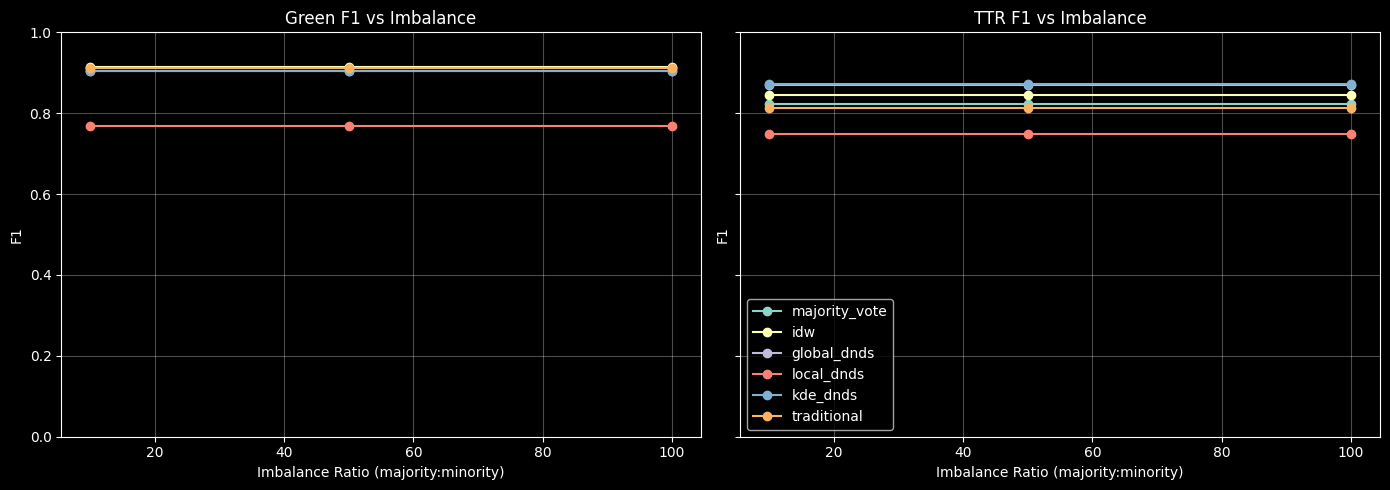

In [17]:
import json
import pandas as pd

save_results(all_results, str(RESULTS_PATH))
save_imbalance_summary_csv(all_results, str(IMBALANCE_CSV_PATH))
plot_minority_f1_vs_imbalance(all_results, str(FIG_PATH))

# if traditional_ready:
#     del traditional_kwargs
# clear_gpu_memory()

print(f"Saved JSON results: {RESULTS_PATH}")
print(f"Saved CSV summary: {IMBALANCE_CSV_PATH}")
print(f"Saved figure: {FIG_PATH}")

# Tabular summary for quick inspection
rows = []
for ratio in all_results.get("ratios", []):
    ratio_key = str(ratio)
    for variant_name, by_ratio in all_results.get("variants", {}).items():
        metrics = by_ratio.get(ratio_key, {})
        per_f1 = metrics.get("per_class_f1", {})
        rows.append(
            {
                "ratio": ratio,
                "variant": variant_name,
                "accuracy": round(float(metrics.get("accuracy", 0.0)), 4),
                "macro_f1": round(float(metrics.get("macro_f1", 0.0)), 4),
                "weighted_f1": round(float(metrics.get("weighted_f1", 0.0)), 4),
                "green_f1": round(float(per_f1.get("Green", 0.0)), 4),
                "ttr_f1": round(float(per_f1.get("TTR", 0.0)), 4),
            }
        )

summary_df = pd.DataFrame(rows).sort_values(["ratio", "variant"]).reset_index(drop=True)

print("\n" + "=" * 80)
print("IMBALANCE RESULTS SUMMARY TABLE")
print("=" * 80)
print(summary_df)